<a href="https://colab.research.google.com/github/240264-sudo/AI-ML-lab/blob/main/AI_ML_LAB_Automobile_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
/from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv("automobile_dataset.csv")
df.info()

Saving automobile_dataset.csv to automobile_dataset.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Make              5500 non-null   object 
 1   Model             5500 non-null   object 
 2   Year              5500 non-null   int64  
 3   Fuel_Type         5500 non-null   object 
 4   Transmission      4673 non-null   object 
 5   Engine_Size       4656 non-null   float64
 6   Mileage           5500 non-null   int64  
 7   Horsepower        4700 non-null   float64
 8   Torque            4701 non-null   float64
 9   Owners            5500 non-null   int64  
 10  Accident_History  4688 non-null   float64
 11  Service_History   4645 non-null   object 
 12  Color             4697 non-null   object 
 13  Body_Type         5500 non-null   object 
 14  Drivetrain        5500 non-null   object 
 15  Fuel_Efficiency   4706 non-null  

In [ ]:
print(df.shape)          # Rows and columns
print(df.dtypes)         # Data types
print(df.isnull().sum()) # Missing values

(5500, 18)
Make                 object
Model                object
Year                  int64
Fuel_Type            object
Transmission         object
Engine_Size         float64
Mileage               int64
Horsepower          float64
Torque              float64
Owners                int64
Accident_History    float64
Service_History      object
Color                object
Body_Type            object
Drivetrain           object
Fuel_Efficiency     float64
Location             object
Selling_Price         int64
dtype: object
Make                  0
Model                 0
Year                  0
Fuel_Type             0
Transmission        827
Engine_Size         844
Mileage               0
Horsepower          800
Torque              799
Owners                0
Accident_History    812
Service_History     855
Color               803
Body_Type             0
Drivetrain            0
Fuel_Efficiency     794
Location            782
Selling_Price         0
dtype: int64


In [ ]:
df.head()
df.tail()
df.sample(5)

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
3136,Honda,Pilot,2012,Petrol,Automatic,3.5,162879,NaN,271.0,2,0.0,NaN,Silver,SUV,RWD,22.0,TX,4926
1728,Chevrolet,Silverado,2006,Petrol,Manual,3.2,244672,244.0,230.0,3,0.0,Partial Service,White,Truck,4WD,26.0,TX,500
5321,Volkswagen,Passat,2023,Hybrid,Automatic,NaN,32523,151.0,145.0,1,0.0,NaN,NaN,Sedan,FWD,43.0,NC,24495
4637,Honda,CR-V,2007,Petrol,Automatic,NaN,198300,257.0,255.0,4,1.0,Partial Service,Silver,SUV,AWD,NaN,OH,500
292,Audi,A4,2017,Petrol,NaN,1.6,67750,125.0,120.0,2,1.0,NaN,NaN,Sedan,FWD,39.0,CA,17232


In [ ]:
# Check missing values
df.isnull().sum()

# Delete rows with missing values (optional)
df = df.dropna()

# Replace missing values in numeric columns with mean
df = df.fillna(df.mean(numeric_only=True))

# Replace missing values in numeric columns with median
df = df.fillna(df.median(numeric_only=True))

# Replace missing values in all columns with mode
df = df.fillna(df.mode().iloc[0])
print(df.isnull().sum())

Make                0
Model               0
Year                0
Fuel_Type           0
Transmission        0
Engine_Size         0
Mileage             0
Horsepower          0
Torque              0
Owners              0
Accident_History    0
Service_History     0
Color               0
Body_Type           0
Drivetrain          0
Fuel_Efficiency     0
Location            0
Selling_Price       0
dtype: int64


In [ ]:
df.duplicated().sum()
df = df.drop_duplicates()
# Number of duplicate rows before removing
print("Duplicate rows before:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Number of duplicate rows after removing
print("Duplicate rows after:", df.duplicated().sum())

# Display first 5 rows
df.head()

Duplicate rows before: 0
Duplicate rows after: 0


,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
4,Toyota,Camry,2022,Petrol,Automatic,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792
7,Mercedes-Benz,C-Class,2022,Petrol,Automatic,2.3,32133,180.0,162.0,1,0.0,Partial Service,Green,Sedan,FWD,35.0,NY,31416
15,Mercedes-Benz,C-Class,2010,Petrol,Manual,2.0,17138,169.0,160.0,3,0.0,Partial Service,Blue,Sedan,FWD,27.0,NC,11728
17,Chevrolet,Tahoe,2011,Petrol,Automatic,3.3,264441,258.0,252.0,4,0.0,Partial Service,Gray,SUV,AWD,22.0,TX,3395
21,Audi,Q7,2016,Petrol,Automatic,3.1,111537,243.0,219.0,2,0.0,Partial Service,Blue,SUV,AWD,21.0,FL,23314


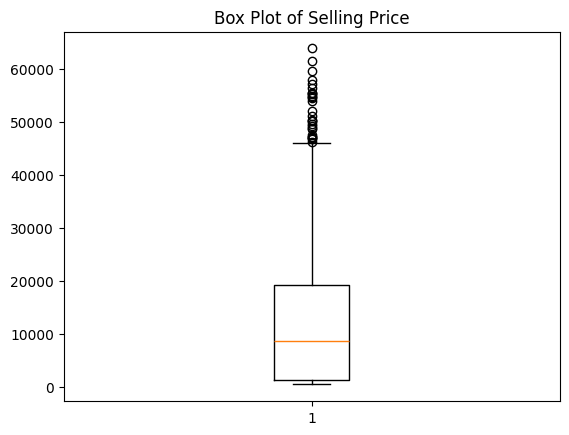

In [ ]:

import matplotlib.pyplot as plt

plt.boxplot(df['Selling_Price'])
plt.title("Box Plot of Selling Price")
plt.show()

In [ ]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Selling_Price'] = df['Selling_Price'].clip(lower, upper)

print(df.head())

             Make    Model  Year Fuel_Type Transmission  Engine_Size  Mileage  \
4          Toyota    Camry  2022    Petrol    Automatic          1.9    32813   
7   Mercedes-Benz  C-Class  2022    Petrol    Automatic          2.3    32133   
15  Mercedes-Benz  C-Class  2010    Petrol       Manual          2.0    17138   
17      Chevrolet    Tahoe  2011    Petrol    Automatic          3.3   264441   
21           Audi       Q7  2016    Petrol    Automatic          3.1   111537   

    Horsepower  Torque  Owners  Accident_History  Service_History  Color  \
4        149.0   141.0       1               0.0     Full Service  Brown   
7        180.0   162.0       1               0.0  Partial Service  Green   
15       169.0   160.0       3               0.0  Partial Service   Blue   
17       258.0   252.0       4               0.0  Partial Service   Gray   
21       243.0   219.0       2               0.0  Partial Service   Blue   

   Body_Type Drivetrain  Fuel_Efficiency Location  Selli

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])

df.head()

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
4,Toyota,Camry,2022,3,Automatic,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792.0
7,Mercedes-Benz,C-Class,2022,3,Automatic,2.3,32133,180.0,162.0,1,0.0,Partial Service,Green,Sedan,FWD,35.0,NY,31416.0
15,Mercedes-Benz,C-Class,2010,3,Manual,2.0,17138,169.0,160.0,3,0.0,Partial Service,Blue,Sedan,FWD,27.0,NC,11728.0
17,Chevrolet,Tahoe,2011,3,Automatic,3.3,264441,258.0,252.0,4,0.0,Partial Service,Gray,SUV,AWD,22.0,TX,3395.0
21,Audi,Q7,2016,3,Automatic,3.1,111537,243.0,219.0,2,0.0,Partial Service,Blue,SUV,AWD,21.0,FL,23314.0


In [ ]:
df = pd.get_dummies(df, columns=['Transmission'])
df.head()

,Make,Model,Year,Fuel_Type,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price,Transmission_Automatic,Transmission_Manual
4,Toyota,Camry,2022,3,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792.0,True,False
7,Mercedes-Benz,C-Class,2022,3,2.3,32133,180.0,162.0,1,0.0,Partial Service,Green,Sedan,FWD,35.0,NY,31416.0,True,False
15,Mercedes-Benz,C-Class,2010,3,2.0,17138,169.0,160.0,3,0.0,Partial Service,Blue,Sedan,FWD,27.0,NC,11728.0,False,True
17,Chevrolet,Tahoe,2011,3,3.3,264441,258.0,252.0,4,0.0,Partial Service,Gray,SUV,AWD,22.0,TX,3395.0,True,False
21,Audi,Q7,2016,3,3.1,111537,243.0,219.0,2,0.0,Partial Service,Blue,SUV,AWD,21.0,FL,23314.0,True,False


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Selling_Price']] = scaler.fit_transform(df[['Selling_Price']])

df.head()

,Make,Model,Year,Fuel_Type,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price,Transmission_Automatic,Transmission_Manual
4,Toyota,Camry,2022,3,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,0.466403,True,False
7,Mercedes-Benz,C-Class,2022,3,2.3,32133,180.0,162.0,1,0.0,Partial Service,Green,Sedan,FWD,35.0,NY,0.677218,True,False
15,Mercedes-Benz,C-Class,2010,3,2.0,17138,169.0,160.0,3,0.0,Partial Service,Blue,Sedan,FWD,27.0,NC,0.245950,False,True
17,Chevrolet,Tahoe,2011,3,3.3,264441,258.0,252.0,4,0.0,Partial Service,Gray,SUV,AWD,22.0,TX,0.063415,True,False
21,Audi,Q7,2016,3,3.1,111537,243.0,219.0,2,0.0,Partial Service,Blue,SUV,AWD,21.0,FL,0.499743,True,False


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Selling_Price']] = scaler.fit_transform(df[['Selling_Price']])

df.head()

,Make,Model,Year,Fuel_Type,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price,Transmission_Automatic,Transmission_Manual
4,Toyota,Camry,2022,3,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,0.796456,True,False
7,Mercedes-Benz,C-Class,2022,3,2.3,32133,180.0,162.0,1,0.0,Partial Service,Green,Sedan,FWD,35.0,NY,1.595406,True,False
15,Mercedes-Benz,C-Class,2010,3,2.0,17138,169.0,160.0,3,0.0,Partial Service,Blue,Sedan,FWD,27.0,NC,-0.039020,False,True
17,Chevrolet,Tahoe,2011,3,3.3,264441,258.0,252.0,4,0.0,Partial Service,Gray,SUV,AWD,22.0,TX,-0.730795,True,False
21,Audi,Q7,2016,3,3.1,111537,243.0,219.0,2,0.0,Partial Service,Blue,SUV,AWD,21.0,FL,0.922807,True,False


In [ ]:
corr = df.corr(numeric_only=True)
print(corr)

                            Year  Fuel_Type  Engine_Size   Mileage  \
Year                    1.000000  -0.148980    -0.086626 -0.758933   
Fuel_Type              -0.148980   1.000000     0.154503  0.125813   
Engine_Size            -0.086626   0.154503     1.000000  0.066223   
Mileage                -0.758933   0.125813     0.066223  1.000000   
Horsepower              0.041470  -0.058374     0.668651 -0.031775   
Torque                  0.056906  -0.090018     0.562644 -0.037816   
Owners                 -0.834137   0.124679     0.098003  0.620957   
Accident_History       -0.415030   0.062610     0.001929  0.332980   
Fuel_Efficiency         0.183235  -0.294509    -0.742051 -0.145966   
Selling_Price           0.820485  -0.110776    -0.041513 -0.700067   
Transmission_Automatic  0.381505  -0.048130    -0.048810 -0.289384   
Transmission_Manual    -0.381505   0.048130     0.048810  0.289384   

                        Horsepower    Torque    Owners  Accident_History  \
Year         

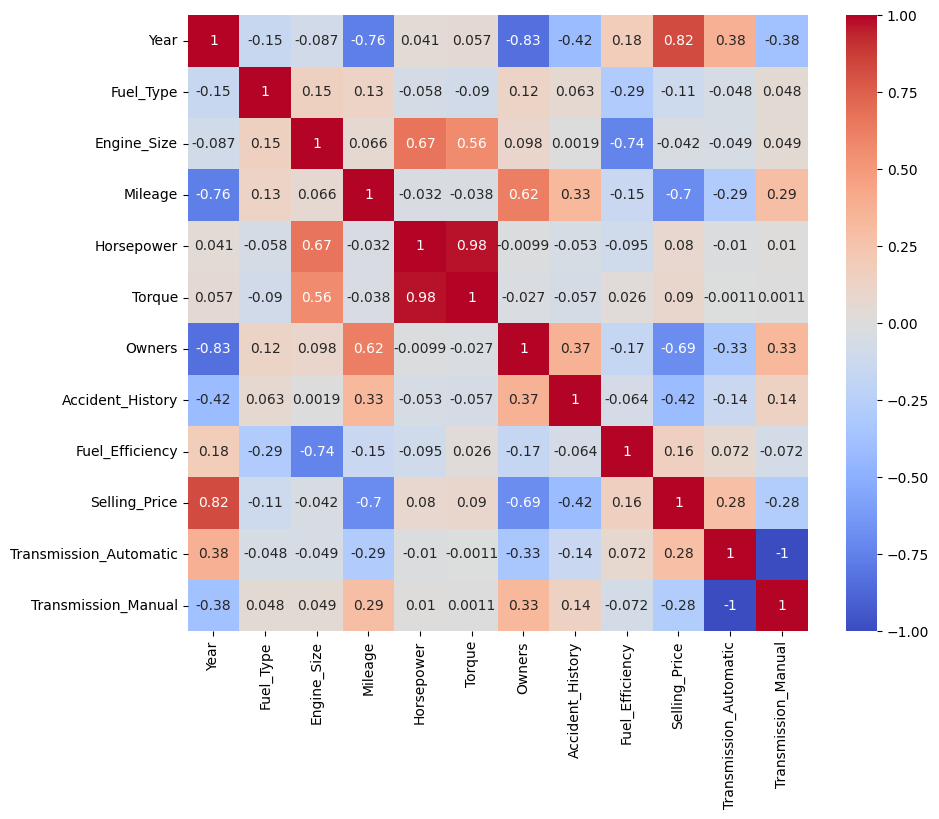

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df['Power_per_Engine'] = df['Horsepower'] / df['Engine_Size']

df.head()

,Make,Model,Year,Fuel_Type,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price,Transmission_Automatic,Transmission_Manual,Power_per_Engine
4,Toyota,Camry,2022,3,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,0.796456,True,False,78.421053
7,Mercedes-Benz,C-Class,2022,3,2.3,32133,180.0,162.0,1,0.0,Partial Service,Green,Sedan,FWD,35.0,NY,1.595406,True,False,78.260870
15,Mercedes-Benz,C-Class,2010,3,2.0,17138,169.0,160.0,3,0.0,Partial Service,Blue,Sedan,FWD,27.0,NC,-0.039020,False,True,84.500000
17,Chevrolet,Tahoe,2011,3,3.3,264441,258.0,252.0,4,0.0,Partial Service,Gray,SUV,AWD,22.0,TX,-0.730795,True,False,78.181818
21,Audi,Q7,2016,3,3.1,111537,243.0,219.0,2,0.0,Partial Service,Blue,SUV,AWD,21.0,FL,0.922807,True,False,78.387097


In [ ]:
df['Year'] = df['Year'].astype(int)
df['Engine_Size'] = df['Engine_Size'].astype(float)

print(df.dtypes)

Make                       object
Model                      object
Year                        int64
Fuel_Type                   int64
Engine_Size               float64
Mileage                     int64
Horsepower                float64
Torque                    float64
Owners                      int64
Accident_History          float64
Service_History            object
Color                      object
Body_Type                  object
Drivetrain                 object
Fuel_Efficiency           float64
Location                   object
Selling_Price             float64
Transmission_Automatic       bool
Transmission_Manual          bool
Power_per_Engine          float64
dtype: object


In [ ]:
df['Color'] = df['Color'].str.strip().str.title()

df.head()

,Make,Model,Year,Fuel_Type,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price,Transmission_Automatic,Transmission_Manual,Power_per_Engine
4,Toyota,Camry,2022,3,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,0.796456,True,False,78.421053
7,Mercedes-Benz,C-Class,2022,3,2.3,32133,180.0,162.0,1,0.0,Partial Service,Green,Sedan,FWD,35.0,NY,1.595406,True,False,78.260870
15,Mercedes-Benz,C-Class,2010,3,2.0,17138,169.0,160.0,3,0.0,Partial Service,Blue,Sedan,FWD,27.0,NC,-0.039020,False,True,84.500000
17,Chevrolet,Tahoe,2011,3,3.3,264441,258.0,252.0,4,0.0,Partial Service,Gray,SUV,AWD,22.0,TX,-0.730795,True,False,78.181818
21,Audi,Q7,2016,3,3.1,111537,243.0,219.0,2,0.0,Partial Service,Blue,SUV,AWD,21.0,FL,0.922807,True,False,78.387097


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1063, 85)
(266, 85)


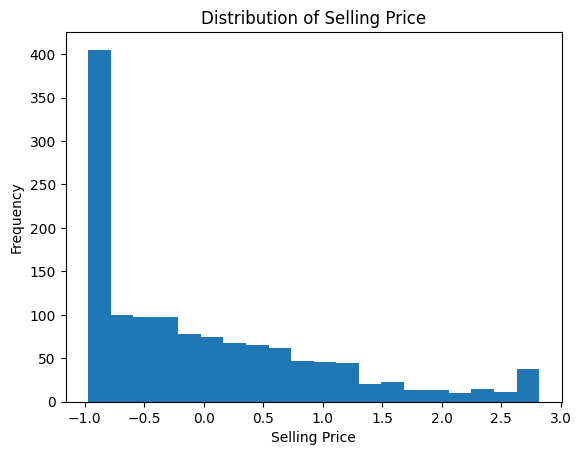

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['Selling_Price'], bins=20)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print(df.head())
print(df.info())

             Make    Model  Year  Fuel_Type  Engine_Size  Mileage  Horsepower  \
4          Toyota    Camry  2022          3          1.9    32813       149.0   
7   Mercedes-Benz  C-Class  2022          3          2.3    32133       180.0   
15  Mercedes-Benz  C-Class  2010          3          2.0    17138       169.0   
17      Chevrolet    Tahoe  2011          3          3.3   264441       258.0   
21           Audi       Q7  2016          3          3.1   111537       243.0   

    Torque  Owners  Accident_History  Service_History  Color Body_Type  \
4    141.0       1               0.0     Full Service  Brown     Sedan   
7    162.0       1               0.0  Partial Service  Green     Sedan   
15   160.0       3               0.0  Partial Service   Blue     Sedan   
17   252.0       4               0.0  Partial Service   Gray       SUV   
21   219.0       2               0.0  Partial Service   Blue       SUV   

   Drivetrain  Fuel_Efficiency Location  Selling_Price  \
4         

In [ ]:
df.to_csv("cleaned_automobile_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
